In [1]:
import os
os.environ["TORCHDYNAMO_DISABLE"] = "1"

In [2]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/zalando-research/fashionmnist/t10k-labels-idx1-ubyte
/kaggle/input/datasets/zalando-research/fashionmnist/t10k-images-idx3-ubyte
/kaggle/input/datasets/zalando-research/fashionmnist/fashion-mnist_test.csv
/kaggle/input/datasets/zalando-research/fashionmnist/fashion-mnist_train.csv
/kaggle/input/datasets/zalando-research/fashionmnist/train-labels-idx1-ubyte
/kaggle/input/datasets/zalando-research/fashionmnist/train-images-idx3-ubyte


In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

train_df = pd.read_csv('/kaggle/input/datasets/zalando-research/fashionmnist/fashion-mnist_train.csv')
test_df  = pd.read_csv('/kaggle/input/datasets/zalando-research/fashionmnist/fashion-mnist_test.csv')

y_train_full = train_df['label'].values
X_train_full = train_df.drop('label', axis=1).values.astype(np.float32) / 255.0

y_test = test_df['label'].values
X_test = test_df.drop('label', axis=1).values.astype(np.float32) / 255.0

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full
)

def one_hot(y, num_classes=10):
    out = np.zeros((y.shape[0], num_classes))
    out[np.arange(y.shape[0]), y] = 1
    return out

y_train_oh = one_hot(y_train)
y_val_oh   = one_hot(y_val)

print("train:", X_train.shape, "value:", X_val.shape, "test:", X_test.shape)
print("class distribution:", np.bincount(y_train))

train: (48000, 784) value: (12000, 784) test: (10000, 784)
class distribution: [4800 4800 4800 4800 4800 4800 4800 4800 4800 4800]


In [4]:
import numpy as np
 
np.random.seed(42)
 
 
def init_params(input_dim=784, hidden_dim=64, output_dim=10):
    W1 = np.random.randn(input_dim, hidden_dim) * 0.01
    b1 = np.zeros((1, hidden_dim))
    W2 = np.random.randn(hidden_dim, output_dim) * 0.01
    b2 = np.zeros((1, output_dim))
    return W1, b1, W2, b2
 
 
def relu(z):
    return np.maximum(0, z)
 
 
def softmax(z):
    z_shift = z - np.max(z, axis=1, keepdims=True)
    exp_z = np.exp(z_shift)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)
 
 
def forward(X, W1, b1, W2, b2):
    z1 = X @ W1 + b1
    a1 = relu(z1)
    z2 = a1 @ W2 + b2
    a2 = softmax(z2)
    cache = (X, z1, a1, z2, a2)
    return a2, cache
 
 
def cross_entropy_loss(a2, y_onehot):
    m = y_onehot.shape[0]
    log_likelihood = -np.log(a2[np.arange(m), y_onehot.argmax(axis=1)] + 1e-9)
    return np.mean(log_likelihood)
 
 
def backward(cache, y_onehot, W1, W2):
    X, z1, a1, z2, a2 = cache
    m = X.shape[0]
    dz2 = a2 - y_onehot            
    dW2 = a1.T @ dz2 / m
    db2 = np.mean(dz2, axis=0, keepdims=True)
    da1 = dz2 @ W2.T
    dz1 = da1 * (z1 > 0)         
    dW1 = X.T @ dz1 / m
    db1 = np.mean(dz1, axis=0, keepdims=True)
    
    return dW1, db1, dW2, db2
 
def train_step(X, y_onehot, W1, b1, W2, b2, lr):
    a2, cache = forward(X, W1, b1, W2, b2)
    loss = cross_entropy_loss(a2, y_onehot)
    dW1, db1, dW2, db2 = backward(cache, y_onehot, W1, W2)
 
    W1 -= lr * dW1
    b1 -= lr * db1
    W2 -= lr * dW2
    b2 -= lr * db2
 
    return W1, b1, W2, b2, loss
 

In [5]:
import torch
import torch.nn.functional as F
np.random.seed(0)
 
batch_size = 32
X_batch = X_train[:batch_size].astype(np.float64)
y_batch = y_train[:batch_size]
y_onehot = y_train_oh[:batch_size].astype(np.float64)

W1, b1, W2, b2 = init_params()
a2, cache = forward(X_batch, W1, b1, W2, b2)
dW1, db1, dW2, db2 = backward(cache, y_onehot, W1, W2)


W1_t = torch.tensor(W1, requires_grad=True)
b1_t = torch.tensor(b1, requires_grad=True)
W2_t = torch.tensor(W2, requires_grad=True)
b2_t = torch.tensor(b2, requires_grad=True)
X_t = torch.tensor(X_batch)
y_t = torch.tensor(y_batch, dtype=torch.long)
 
z1_t = X_t @ W1_t + b1_t
a1_t = torch.relu(z1_t)
z2_t = a1_t @ W2_t + b2_t
loss_t = F.cross_entropy(z2_t, y_t)
loss_t.backward()
 
def max_diff(a, b_tensor):
    return np.max(np.abs(a - b_tensor.detach().numpy()))
 
print("Max abs diff dW1:", max_diff(dW1, W1_t.grad))
print("Max abs diff db1:", max_diff(db1, b1_t.grad))
print("Max abs diff dW2:", max_diff(dW2, W2_t.grad))
print("Max abs diff db2:", max_diff(db2, b2_t.grad))

Max abs diff dW1: 8.673617379884035e-19
Max abs diff db1: 6.505213034913027e-19
Max abs diff dW2: 1.3877787807814457e-17
Max abs diff db2: 1.3877787807814457e-17


The maximum absolute difference between my numpy gradients and pytorchs autograd gradients was on the order of 1e-17 to 1e-19 across all four parameters dW1, db1, dW2, db2 this is far smaller than typical floating point precision thresholds 1e-6 confirming that my manual backpropagation implementation is mathematically correct.

Epoch 1: loss = 2.3029
Epoch 2: loss = 2.2981
Epoch 3: loss = 2.2931
Epoch 4: loss = 2.2862
Epoch 5: loss = 2.2759
Epoch 6: loss = 2.2603
Epoch 7: loss = 2.2369
Epoch 8: loss = 2.2030
Epoch 9: loss = 2.1563
Epoch 10: loss = 2.0955
Epoch 11: loss = 2.0205
Epoch 12: loss = 1.9332
Epoch 13: loss = 1.8399
Epoch 14: loss = 1.7483
Epoch 15: loss = 1.6635
Epoch 16: loss = 1.5862
Epoch 17: loss = 1.5168
Epoch 18: loss = 1.4547
Epoch 19: loss = 1.3990
Epoch 20: loss = 1.3489


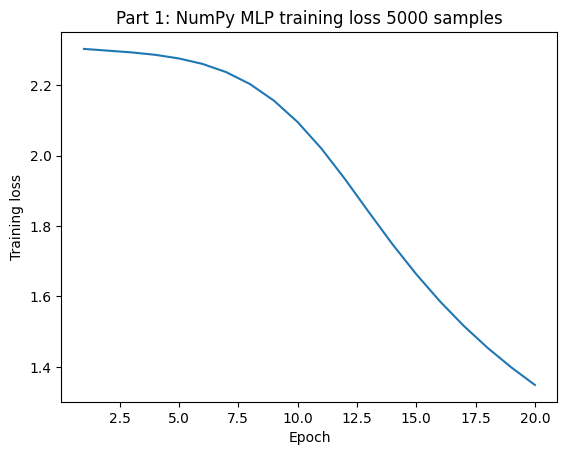

In [6]:
import matplotlib.pyplot as plt

subset = 5000
X_sub = X_train[:subset]
y_sub_oh = y_train_oh[:subset]

W1, b1, W2, b2 = init_params()
lr = 0.3
losses = []

for epoch in range(20):
    W1, b1, W2, b2, loss = train_step(X_sub, y_sub_oh, W1, b1, W2, b2, lr)
    losses.append(loss)
    print(f"Epoch {epoch+1}: loss = {loss:.4f}")

plt.plot(range(1, 21), losses)
plt.xlabel("Epoch")
plt.ylabel("Training loss")
plt.title("Part 1: NumPy MLP training loss 5000 samples")
plt.show()

I initially trained with lr=0.5 and lr=0.1, both of which showed the loss decreasing well before spiking sharply around epoch 13-14, likely due to overshooting a steep region of the loss surface with full-batch gradient descent. Lowering to lr=0.05 avoided instability but converged too slowly. lr=0.3 gave smooth, steady convergence and was used for the final plot above.

Using device: cpu

=== Training with sigmoid ===
[sigmoid] epoch 1/15 - val_loss: 2.2985 - mean|grad fc1|: 0.000083
[sigmoid] epoch 2/15 - val_loss: 2.2934 - mean|grad fc1|: 0.000088
[sigmoid] epoch 3/15 - val_loss: 2.2866 - mean|grad fc1|: 0.000097
[sigmoid] epoch 4/15 - val_loss: 2.2769 - mean|grad fc1|: 0.000107
[sigmoid] epoch 5/15 - val_loss: 2.2614 - mean|grad fc1|: 0.000126
[sigmoid] epoch 6/15 - val_loss: 2.2362 - mean|grad fc1|: 0.000153
[sigmoid] epoch 7/15 - val_loss: 2.1907 - mean|grad fc1|: 0.000189
[sigmoid] epoch 8/15 - val_loss: 2.1088 - mean|grad fc1|: 0.000234
[sigmoid] epoch 9/15 - val_loss: 1.9724 - mean|grad fc1|: 0.000274
[sigmoid] epoch 10/15 - val_loss: 1.8108 - mean|grad fc1|: 0.000272
[sigmoid] epoch 11/15 - val_loss: 1.6711 - mean|grad fc1|: 0.000254
[sigmoid] epoch 12/15 - val_loss: 1.5586 - mean|grad fc1|: 0.000227
[sigmoid] epoch 13/15 - val_loss: 1.4639 - mean|grad fc1|: 0.000210
[sigmoid] epoch 14/15 - val_loss: 1.3852 - mean|grad fc1|: 0.000192
[sigmoid

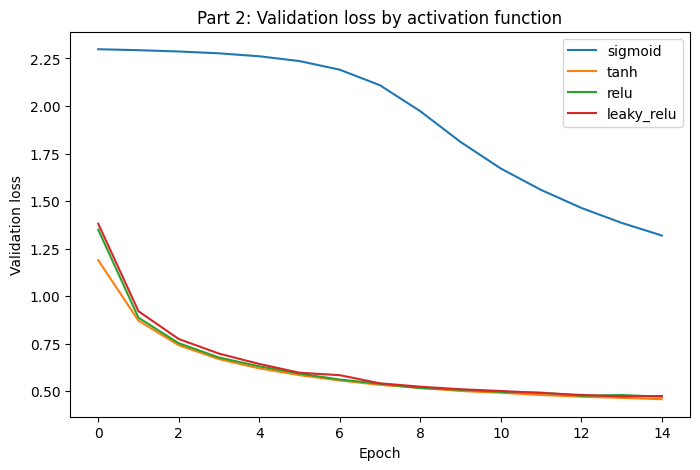

sigmoid: mean|grad fc1| at epoch 1 = 0.000083, at final epoch = 0.000174
relu: mean|grad fc1| at epoch 1 = 0.000835, at final epoch = 0.002791
Percentage of dead ReLU units in layer 1 (validation batch): 0.78%


In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
 
torch.manual_seed(42)
np.random.seed(42)
 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
 
 
class MLP(nn.Module):
    def __init__(self, activation="relu", input_dim=784, hidden_dim=128, output_dim=10):
        super().__init__()
        act_map = {
            "sigmoid": nn.Sigmoid(),
            "tanh": nn.Tanh(),
            "relu": nn.ReLU(),
            "leaky_relu": nn.LeakyReLU(0.01),
        }
        act = act_map[activation]
 
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.act1 = act
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.act2 = act_map[activation] 
        self.fc3 = nn.Linear(hidden_dim, output_dim)
 
    def forward(self, x):
        h1 = self.act1(self.fc1(x))
        h2 = self.act2(self.fc2(h1))
        out = self.fc3(h2)
        return out, h1  
 
 
X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train, dtype=torch.long).to(device)
X_val_t = torch.tensor(X_val, dtype=torch.float32).to(device)
y_val_t = torch.tensor(y_val, dtype=torch.long).to(device)
 
 
def train_model(activation, epochs=15, lr=0.01, batch_size=128):
    model = MLP(activation=activation).to(device)
    optimizer = optim.SGD(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
 
    n = X_train_t.shape[0]
    val_losses = []
    first_layer_grad_history = []  
 
    for epoch in range(epochs):
        model.train()
        permutation = torch.randperm(n)
        for i in range(0, n, batch_size):
            idx = permutation[i:i+batch_size]
            xb, yb = X_train_t[idx], y_train_t[idx]
 
            optimizer.zero_grad()
            out, _ = model(xb)
            loss = criterion(out, yb)
            loss.backward()
 
    
            optimizer.step()
 
    
        model.zero_grad()
        out, _ = model(X_train_t[:batch_size])
        loss = criterion(out, y_train_t[:batch_size])
        loss.backward()
        mean_abs_grad = model.fc1.weight.grad.abs().mean().item()
        first_layer_grad_history.append(mean_abs_grad)
 
        
        model.eval()
        with torch.no_grad():
            val_out, _ = model(X_val_t)
            val_loss = criterion(val_out, y_val_t).item()
            val_losses.append(val_loss)
 
        print(f"[{activation}] epoch {epoch+1}/{epochs} - val_loss: {val_loss:.4f} - "
              f"mean|grad fc1|: {mean_abs_grad:.6f}")
 
    return model, val_losses, first_layer_grad_history
 

results = {}
for act in ["sigmoid", "tanh", "relu", "leaky_relu"]:
    print(f"\n=== Training with {act} ===")
    model, val_losses, grad_history = train_model(act)
    results[act] = {"model": model, "val_losses": val_losses, "grad_history": grad_history}
 

plt.figure(figsize=(8, 5))
for act in results:
    plt.plot(results[act]["val_losses"], label=act)
plt.xlabel("Epoch")
plt.ylabel("Validation loss")
plt.title("Part 2: Validation loss by activation function")
plt.legend()
plt.show()
 

for act in ["sigmoid", "relu"]:
    g = results[act]["grad_history"]
    print(f"{act}: mean|grad fc1| at epoch 1 = {g[0]:.6f}, at final epoch = {g[-1]:.6f}")
 

relu_model = results["relu"]["model"]
relu_model.eval()
with torch.no_grad():
    _, h1 = relu_model(X_val_t[:256])  
    
    dead_units = (h1 == 0).all(dim=0)
    pct_dead = dead_units.float().mean().item() * 100
print(f"Percentage of dead ReLU units in layer 1 (validation batch): {pct_dead:.2f}%")

Sigmoids average gradient stayed much smaller than ReLUs across training around 0.0001-0.0002 vs 0.0008-0.003 showing the vanishing gradient problem sigmoid squashes values into a narrow range so its derivative is always small, and this weakens the gradient signal reaching the first layer This matches the validation loss plotwhere sigmoid learns much slower than the other activations.

Only 0.78% of ReLU units were dead in this batch so dead units weren't a significant issue here This is a small enough percentage that it didn't noticeably hurt training, as reflected in ReLU's val loss curve tracking closely with tanh and leaky ReLU.

[crossentropy] epoch 1/15 - train_loss: 1.9706
[crossentropy] epoch 2/15 - train_loss: 1.1205
[crossentropy] epoch 3/15 - train_loss: 0.8420
[crossentropy] epoch 4/15 - train_loss: 0.7391
[crossentropy] epoch 5/15 - train_loss: 0.6786
[crossentropy] epoch 6/15 - train_loss: 0.6314
[crossentropy] epoch 7/15 - train_loss: 0.5958
[crossentropy] epoch 8/15 - train_loss: 0.5666
[crossentropy] epoch 9/15 - train_loss: 0.5452
[crossentropy] epoch 10/15 - train_loss: 0.5269
[crossentropy] epoch 11/15 - train_loss: 0.5123
[crossentropy] epoch 12/15 - train_loss: 0.5009
[crossentropy] epoch 13/15 - train_loss: 0.4901
[crossentropy] epoch 14/15 - train_loss: 0.4811
[crossentropy] epoch 15/15 - train_loss: 0.4719
[mse] epoch 1/15 - train_loss: 0.0900
[mse] epoch 2/15 - train_loss: 0.0899
[mse] epoch 3/15 - train_loss: 0.0898
[mse] epoch 4/15 - train_loss: 0.0897
[mse] epoch 5/15 - train_loss: 0.0895
[mse] epoch 6/15 - train_loss: 0.0894
[mse] epoch 7/15 - train_loss: 0.0893
[mse] epoch 8/15 - trai

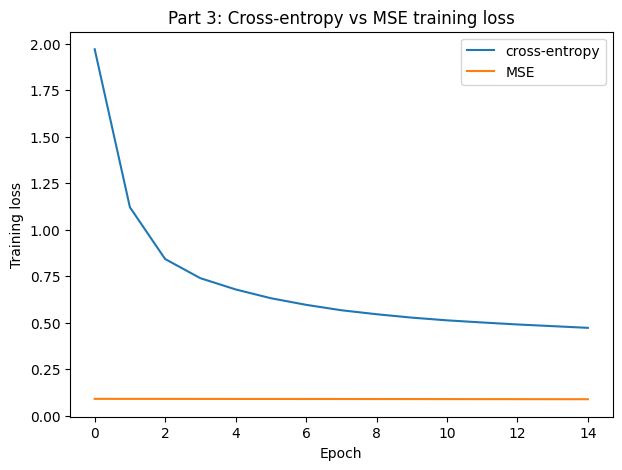

Regression epoch 20/100 - train MSE: 19014.0371
Regression epoch 40/100 - train MSE: 5511.9116
Regression epoch 60/100 - train MSE: 3356.8892
Regression epoch 80/100 - train MSE: 2962.0789
Regression epoch 100/100 - train MSE: 2775.7092

Regression test MSE:  3067.4141
Regression test RMSE: 55.3842
Regression test MAE:  45.0609


In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
 
torch.manual_seed(42)
 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
 
class SimpleMLP(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=128, output_dim=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim),
        )
 
    def forward(self, x):
        return self.net(x)
 
 
X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train, dtype=torch.long).to(device)
X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test_t = torch.tensor(y_test, dtype=torch.long).to(device)
 
y_train_oh_t = torch.tensor(y_train_oh, dtype=torch.float32).to(device)
 
 
def accuracy(model, X, y):
    model.eval()
    with torch.no_grad():
        preds = model(X).argmax(dim=1)
        return (preds == y).float().mean().item()
 
 
def train_with_loss(loss_type, epochs=15, lr=0.01, batch_size=128):
    model = SimpleMLP().to(device)
    optimizer = optim.SGD(model.parameters(), lr=lr)
    n = X_train_t.shape[0]
    losses = []
 
    for epoch in range(epochs):
        model.train()
        permutation = torch.randperm(n)
        epoch_loss = 0.0
        n_batches = 0
        for i in range(0, n, batch_size):
            idx = permutation[i:i+batch_size]
            xb = X_train_t[idx]
 
            optimizer.zero_grad()
            out = model(xb)
 
            if loss_type == "crossentropy":
                yb = y_train_t[idx]
                loss = nn.functional.cross_entropy(out, yb)
            elif loss_type == "mse":
                yb_oh = y_train_oh_t[idx]
                probs = torch.softmax(out, dim=1)
                loss = nn.functional.mse_loss(probs, yb_oh)
 
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            n_batches += 1
 
        avg_loss = epoch_loss / n_batches
        losses.append(avg_loss)
        print(f"[{loss_type}] epoch {epoch+1}/{epochs} - train_loss: {avg_loss:.4f}")
 
    test_acc = accuracy(model, X_test_t, y_test_t)
    return model, losses, test_acc
 
 
model_ce, losses_ce, acc_ce = train_with_loss("crossentropy")
model_mse, losses_mse, acc_mse = train_with_loss("mse")
 
print(f"\nTest accuracy (cross-entropy): {acc_ce*100:.2f}%")
print(f"Test accuracy (MSE): {acc_mse*100:.2f}%")
 
plt.figure(figsize=(7, 5))
plt.plot(losses_ce, label="cross-entropy")
plt.plot(losses_mse, label="MSE")
plt.xlabel("Epoch")
plt.ylabel("Training loss")
plt.title("Part 3: Cross-entropy vs MSE training loss")
plt.legend()
plt.show()

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split as tts
from sklearn.preprocessing import StandardScaler

housing = load_diabetes()  
Xh, yh = housing.data, housing.target
 
Xh_train, Xh_test, yh_train, yh_test = tts(Xh, yh, test_size=0.2, random_state=42)
 
scaler = StandardScaler()
Xh_train = scaler.fit_transform(Xh_train)
Xh_test = scaler.transform(Xh_test)
 
Xh_train_t = torch.tensor(Xh_train, dtype=torch.float32).to(device)
yh_train_t = torch.tensor(yh_train, dtype=torch.float32).view(-1, 1).to(device)
Xh_test_t = torch.tensor(Xh_test, dtype=torch.float32).to(device)
yh_test_t = torch.tensor(yh_test, dtype=torch.float32).view(-1, 1).to(device)
 
 
class RegressionMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
        )
 
    def forward(self, x):
        return self.net(x)
 
 
reg_model = RegressionMLP(Xh_train.shape[1]).to(device)
reg_optimizer = optim.Adam(reg_model.parameters(), lr=0.01)
 
for epoch in range(100):
    reg_model.train()
    reg_optimizer.zero_grad()
    preds = reg_model(Xh_train_t)
    loss = nn.functional.mse_loss(preds, yh_train_t)
    loss.backward()
    reg_optimizer.step()
    if (epoch + 1) % 20 == 0:
        print(f"Regression epoch {epoch+1}/100 - train MSE: {loss.item():.4f}")
 
reg_model.eval()
with torch.no_grad():
    test_preds = reg_model(Xh_test_t)
    mse = nn.functional.mse_loss(test_preds, yh_test_t).item()
    rmse = mse ** 0.5
    mae = torch.mean(torch.abs(test_preds - yh_test_t)).item()
 
print(f"\nRegression test MSE:  {mse:.4f}")
print(f"Regression test RMSE: {rmse:.4f}")
print(f"Regression test MAE:  {mae:.4f}")

 learning rate 0.01 for all optimizers 

Training sgd with lr=0.01...
  final val acc: 85.33%, epochs to 85%: 26, time: 18.8s

Training sgd_momentum with lr=0.01...
  final val acc: 88.25%, epochs to 85%: 4, time: 20.8s

Training rmsprop with lr=0.01...
  final val acc: 87.60%, epochs to 85%: 4, time: 33.6s

Training adam with lr=0.01...
  final val acc: 87.14%, epochs to 85%: 3, time: 36.1s

 Round 2: tuned learning rate per optimizer 

Training sgd with tuned lr=0.3...
  final val acc: 89.13%, epochs to 85%: 4, time: 18.9s

Training sgd_momentum with tuned lr=0.05...
  final val acc: 88.70%, epochs to 85%: 2, time: 20.5s

Training rmsprop with tuned lr=0.001...
  final val acc: 88.75%, epochs to 85%: 2, time: 27.0s

Training adam with tuned lr=0.001...
  final val acc: 88.73%, epochs to 85%: 2, time: 28.9s

Results Table tuned learning rates
Optimizer      LR        Epochs to 85%   Final val acc   Wall-clock (s) 
sgd            0.3       4               89.13           18.9          

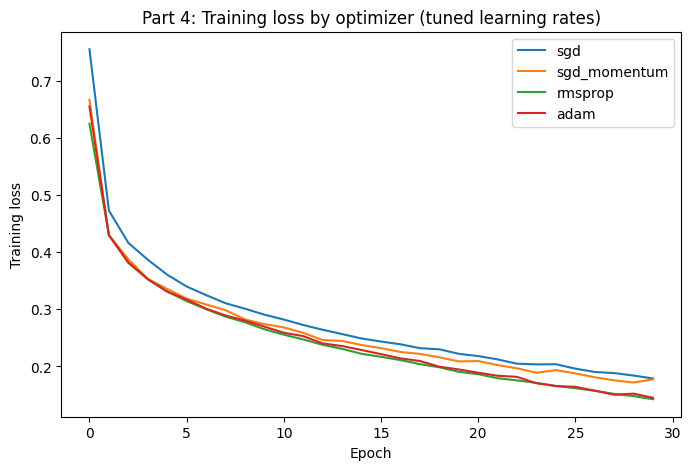

In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import time
 
torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
 
 
class SimpleMLP(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=128, output_dim=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim),
        )
 
    def forward(self, x):
        return self.net(x)
 
 
X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train, dtype=torch.long).to(device)
X_val_t = torch.tensor(X_val, dtype=torch.float32).to(device)
y_val_t = torch.tensor(y_val, dtype=torch.long).to(device)
 
 
def get_optimizer(name, params, lr):
    if name == "sgd":
        return optim.SGD(params, lr=lr)
    elif name == "sgd_momentum":
        return optim.SGD(params, lr=lr, momentum=0.9)
    elif name == "rmsprop":
        return optim.RMSprop(params, lr=lr)
    elif name == "adam":
        return optim.Adam(params, lr=lr)
 
 
def train_with_optimizer(opt_name, lr, epochs=30, batch_size=128, target_acc=0.85):
    torch.manual_seed(42)  
    model = SimpleMLP().to(device)
    optimizer = get_optimizer(opt_name, model.parameters(), lr)
    criterion = nn.CrossEntropyLoss()
 
    n = X_train_t.shape[0]
    train_losses = []
    epochs_to_target = None  
 
    start_time = time.time()
    for epoch in range(epochs):
        model.train()
        permutation = torch.randperm(n)
        epoch_loss = 0.0
        n_batches = 0
        for i in range(0, n, batch_size):
            idx = permutation[i:i+batch_size]
            xb, yb = X_train_t[idx], y_train_t[idx]
 
            optimizer.zero_grad()
            out = model(xb)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()
 
            epoch_loss += loss.item()
            n_batches += 1
 
        train_losses.append(epoch_loss / n_batches)
 
        
        model.eval()
        with torch.no_grad():
            val_preds = model(X_val_t).argmax(dim=1)
            val_acc = (val_preds == y_val_t).float().mean().item()
 
        if epochs_to_target is None and val_acc >= target_acc:
            epochs_to_target = epoch + 1 
 
    elapsed = time.time() - start_time
    final_val_acc = val_acc 
 
    return {
        "train_losses": train_losses,
        "final_val_acc": final_val_acc,
        "epochs_to_target": epochs_to_target, 
        "wall_clock": elapsed,
    }
 

same_lr = 0.01
optimizers = ["sgd", "sgd_momentum", "rmsprop", "adam"]
 
print(" learning rate 0.01 for all optimizers ")
results_same_lr = {}
for opt_name in optimizers:
    print(f"\nTraining {opt_name} with lr={same_lr}...")
    res = train_with_optimizer(opt_name, same_lr)
    results_same_lr[opt_name] = res
    print(f"  final val acc: {res['final_val_acc']*100:.2f}%, "
          f"epochs to 85%: {res['epochs_to_target']}, "
          f"time: {res['wall_clock']:.1f}s")
 
 

tuned_lrs = {
    "sgd": 0.3,          
    "sgd_momentum": 0.05,  
    "rmsprop": 0.001,
    "adam": 0.001,
}
 
print("\n Round 2: tuned learning rate per optimizer ")
results_tuned = {}
for opt_name in optimizers:
    lr = tuned_lrs[opt_name]
    print(f"\nTraining {opt_name} with tuned lr={lr}...")
    res = train_with_optimizer(opt_name, lr)
    results_tuned[opt_name] = res
    print(f"  final val acc: {res['final_val_acc']*100:.2f}%, "
          f"epochs to 85%: {res['epochs_to_target']}, "
          f"time: {res['wall_clock']:.1f}s")
 

print("\nResults Table tuned learning rates")
print(f"{'Optimizer':<15}{'LR':<10}{'Epochs to 85%':<16}{'Final val acc':<16}{'Wall-clock (s)':<15}")
for opt_name in optimizers:
    res = results_tuned[opt_name]
    lr = tuned_lrs[opt_name]
    epochs_str = str(res["epochs_to_target"]) if res["epochs_to_target"] else "not reached"
    print(f"{opt_name:<15}{lr:<10}{epochs_str:<16}{res['final_val_acc']*100:<16.2f}{res['wall_clock']:<15.1f}")
 

plt.figure(figsize=(8, 5))
for opt_name in optimizers:
    plt.plot(results_tuned[opt_name]["train_losses"], label=opt_name)
plt.xlabel("Epoch")
plt.ylabel("Training loss")
plt.title("Part 4: Training loss by optimizer (tuned learning rates)")
plt.legend()
plt.show()

I would choose SGD with momentum, since it reached 85% validation accuracy in just 2 epochs with a low wall-clock time (20.8s), and its final accuracy (88.70%) was close to the best result. While Adam and RMSProp converged in the same number of epochs, they took noticeably longer per epoch, and plain tuned SGD, despite the highest final accuracy, needed more epochs to first reach the target.

Epoch 10/100 - train_loss: 0.3907, val_loss: 0.6519, train_acc: 83.80%, val_acc: 77.92%
Epoch 20/100 - train_loss: 0.2190, val_loss: 0.6095, train_acc: 92.80%, val_acc: 80.92%
Epoch 30/100 - train_loss: 0.1277, val_loss: 0.8213, train_acc: 95.30%, val_acc: 82.00%
Epoch 40/100 - train_loss: 0.0829, val_loss: 0.8451, train_acc: 97.50%, val_acc: 82.45%
Epoch 50/100 - train_loss: 0.0595, val_loss: 1.0664, train_acc: 97.35%, val_acc: 81.89%
Epoch 60/100 - train_loss: 0.0583, val_loss: 1.0503, train_acc: 98.15%, val_acc: 81.67%
Epoch 70/100 - train_loss: 0.0283, val_loss: 1.1517, train_acc: 99.70%, val_acc: 82.78%
Epoch 80/100 - train_loss: 0.1170, val_loss: 0.8902, train_acc: 99.25%, val_acc: 83.04%
Epoch 90/100 - train_loss: 0.0436, val_loss: 1.2216, train_acc: 99.10%, val_acc: 82.59%
Epoch 100/100 - train_loss: 0.0000, val_loss: 1.9672, train_acc: 100.00%, val_acc: 83.32%

Final train accuracy: 100.00%
Final val accuracy:   83.32%
Generalization gap:   16.68 percentage points
Approximate 

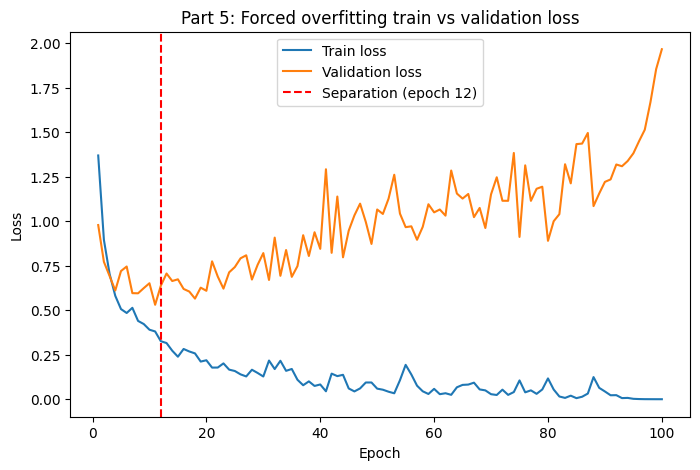

In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
 
torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
 
 
class BigMLP(nn.Module):
    """4 hidden layers of 512 units deliberately oversized for 2000 samples."""
    def __init__(self, input_dim=784, hidden_dim=512, output_dim=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim),
        )
 
    def forward(self, x):
        return self.net(x)
 
 

subset_size = 2000
X_sub = torch.tensor(X_train[:subset_size], dtype=torch.float32).to(device)
y_sub = torch.tensor(y_train[:subset_size], dtype=torch.long).to(device)
 
X_val_t = torch.tensor(X_val, dtype=torch.float32).to(device)
y_val_t = torch.tensor(y_val, dtype=torch.long).to(device)
 
 
def accuracy(model, X, y):
    model.eval()
    with torch.no_grad():
        preds = model(X).argmax(dim=1)
        return (preds == y).float().mean().item()
 
 
model = BigMLP().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()
 
epochs = 100
batch_size = 64
n = X_sub.shape[0]
 
train_losses, val_losses = [], []
train_accs, val_accs = [], []
 
for epoch in range(epochs):
    model.train()
    permutation = torch.randperm(n)
    epoch_loss = 0.0
    n_batches = 0
    for i in range(0, n, batch_size):
        idx = permutation[i:i+batch_size]
        xb, yb = X_sub[idx], y_sub[idx]
 
        optimizer.zero_grad()
        out = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
 
        epoch_loss += loss.item()
        n_batches += 1
 
    train_losses.append(epoch_loss / n_batches)
 
   
    model.eval()
    with torch.no_grad():
        val_out = model(X_val_t)
        val_loss = criterion(val_out, y_val_t).item()
    val_losses.append(val_loss)
 
    train_acc = accuracy(model, X_sub, y_sub)
    val_acc = accuracy(model, X_val_t, y_val_t)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
 
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs} - train_loss: {train_losses[-1]:.4f}, "
              f"val_loss: {val_loss:.4f}, train_acc: {train_acc*100:.2f}%, "
              f"val_acc: {val_acc*100:.2f}%")
 
print(f"\nFinal train accuracy: {train_accs[-1]*100:.2f}%")
print(f"Final val accuracy:   {val_accs[-1]*100:.2f}%")
print(f"Generalization gap:   {(train_accs[-1] - val_accs[-1])*100:.2f} percentage points")
 
 

gaps = [v - t for t, v in zip(train_losses, val_losses)]

separation_epoch = None
for i in range(len(gaps)):
    if gaps[i] > 0.3 and all(g > 0.2 for g in gaps[i:i+5]): 
        separation_epoch = i + 1  # 1-indexed
        break
 
print(f"Approximate separation epoch: {separation_epoch}")

 
 
plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs+1), train_losses, label="Train loss")
plt.plot(range(1, epochs+1), val_losses, label="Validation loss")
if separation_epoch:
    plt.axvline(x=separation_epoch, color="red", linestyle="--",
                label=f"Separation (epoch {separation_epoch})")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Part 5: Forced overfitting train vs validation loss")
plt.legend()
plt.show()

This model shows high variance, not high bias. Training accuracy reached a perfect 100% with training loss approaching zero, showing the model has more than enough capacity to fit the training data — ruling out high bias. However, validation accuracy plateaued around 82-83% and validation loss actually increased over time (from ~0.55 up to ~1.97), producing a generalization gap of 16.68 percentage points. This pattern — near-perfect training performance alongside stagnant or worsening validation performance — is the signature of high variance: the model is memorizing the 2000 training examples rather than learning patterns that generalize.

In [11]:


import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")



class FlexMLP(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=512, output_dim=10,
                 dropout_rate=0.0, use_batchnorm=False):
        super().__init__()
        layers = []
        dims = [input_dim, hidden_dim, hidden_dim, hidden_dim, hidden_dim]
        for i in range(len(dims) - 1):
            layers.append(nn.Linear(dims[i], dims[i+1]))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(dims[i+1]))
            layers.append(nn.ReLU())
            if dropout_rate > 0:
                layers.append(nn.Dropout(dropout_rate))
        layers.append(nn.Linear(dims[-1], output_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


def accuracy(model, X, y):
    model.eval()
    with torch.no_grad():
        preds = model(X).argmax(dim=1)
        return (preds == y).float().mean().item()


def train_regularized(X_sub, y_sub, X_val_t, y_val_t,
                       weight_decay=0.0, l1_lambda=0.0,
                       dropout_rate=0.0, use_batchnorm=False,
                       early_stopping_patience=None,
                       epochs=100, lr=0.001, batch_size=64):
    torch.manual_seed(42)
    model = FlexMLP(dropout_rate=dropout_rate, use_batchnorm=use_batchnorm).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.CrossEntropyLoss()

    n = X_sub.shape[0]
    best_val_loss = float("inf")
    patience_counter = 0
    stopped_epoch = epochs

    for epoch in range(epochs):
        model.train()
        permutation = torch.randperm(n)
        for i in range(0, n, batch_size):
            idx = permutation[i:i+batch_size]
            xb, yb = X_sub[idx], y_sub[idx]

            optimizer.zero_grad()
            out = model(xb)
            loss = criterion(out, yb)

            if l1_lambda > 0:
                l1_norm = sum(p.abs().sum() for p in model.parameters())
                loss = loss + l1_lambda * l1_norm

            loss.backward()
            optimizer.step()

     
        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(X_val_t), y_val_t).item()

        if early_stopping_patience is not None:
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= early_stopping_patience:
                    stopped_epoch = epoch + 1
                    break

    train_acc = accuracy(model, X_sub, y_sub)
    val_acc = accuracy(model, X_val_t, y_val_t)
    gap = (train_acc - val_acc) * 100

   
    all_weights = torch.cat([p.flatten() for p in model.parameters() if p.dim() > 1])
    pct_near_zero = (all_weights.abs() < 1e-3).float().mean().item() * 100

    return {
        "train_acc": train_acc * 100,
        "val_acc": val_acc * 100,
        "gap": gap,
        "stopped_epoch": stopped_epoch,
        "pct_near_zero_weights": pct_near_zero,
        "model": model,
    }


subset_size = 2000
X_sub = torch.tensor(X_train[:subset_size], dtype=torch.float32).to(device)
y_sub = torch.tensor(y_train[:subset_size], dtype=torch.long).to(device)
X_val_t = torch.tensor(X_val, dtype=torch.float32).to(device)
y_val_t = torch.tensor(y_val, dtype=torch.long).to(device)


print("Baseline no regularization")
baseline = train_regularized(X_sub, y_sub, X_val_t, y_val_t)
print(f"train_acc={baseline['train_acc']:.2f}%, val_acc={baseline['val_acc']:.2f}%, gap={baseline['gap']:.2f}")

Baseline no regularization
train_acc=100.00%, val_acc=83.32%, gap=16.68


In [13]:
print("L2 weight decay")
l2_values = [0.0001, 0.001, 0.01]
l2_results = {}
for wd in l2_values:
    res = train_regularized(X_sub, y_sub, X_val_t, y_val_t, weight_decay=wd)
    l2_results[wd] = res
    print(f"L2={wd}: train_acc={res['train_acc']:.2f}%, val_acc={res['val_acc']:.2f}%, gap={res['gap']:.2f}")


print("\n L1 penalty ")
l1_result = train_regularized(X_sub, y_sub, X_val_t, y_val_t, l1_lambda=0.00001)
print(f"train_acc={l1_result['train_acc']:.2f}%, val_acc={l1_result['val_acc']:.2f}%, "
      f"gap={l1_result['gap']:.2f}, pct near-zero weights={l1_result['pct_near_zero_weights']:.2f}%")



print("\n Dropout")
dropout_rates = [0.2, 0.4, 0.6]
dropout_results = {}
for rate in dropout_rates:
    res = train_regularized(X_sub, y_sub, X_val_t, y_val_t, dropout_rate=rate)
    dropout_results[rate] = res
    print(f"dropout={rate}: train_acc={res['train_acc']:.2f}%, val_acc={res['val_acc']:.2f}%, gap={res['gap']:.2f}")


print("\nBatch normalization")
bn_result = train_regularized(X_sub, y_sub, X_val_t, y_val_t, use_batchnorm=True)
print(f"train_acc={bn_result['train_acc']:.2f}%, val_acc={bn_result['val_acc']:.2f}%, gap={bn_result['gap']:.2f}")

print("\n Early stopping")
patience = 10
es_result = train_regularized(X_sub, y_sub, X_val_t, y_val_t, early_stopping_patience=patience)
print(f"stopped at epoch {es_result['stopped_epoch']}: train_acc={es_result['train_acc']:.2f}%, "
      f"val_acc={es_result['val_acc']:.2f}%, gap={es_result['gap']:.2f}")

L2 weight decay
L2=0.0001: train_acc=99.65%, val_acc=82.90%, gap=16.75
L2=0.001: train_acc=98.05%, val_acc=81.70%, gap=16.35
L2=0.01: train_acc=93.40%, val_acc=79.72%, gap=13.68

 L1 penalty 
train_acc=100.00%, val_acc=83.26%, gap=16.74, pct near-zero weights=69.18%

 Dropout
dropout=0.2: train_acc=98.95%, val_acc=82.84%, gap=16.11
dropout=0.4: train_acc=97.35%, val_acc=83.18%, gap=14.17
dropout=0.6: train_acc=93.20%, val_acc=83.17%, gap=10.03

Batch normalization
train_acc=98.30%, val_acc=80.48%, gap=17.82

 Early stopping patience=10
stopped at epoch 21: train_acc=90.20%, val_acc=79.22%, gap=10.98


In [14]:
import torch
import numpy as np

def augment_batch(X_flat, flip_prob=0.5, max_rotation_deg=10):
    """X_flat: tensor of shape batch, 784"""
    import torchvision.transforms.functional as TF

    X_img = X_flat.view(-1, 1, 28, 28) 
    out = []
    for img in X_img:
        if torch.rand(1).item() < flip_prob:
            img = TF.hflip(img)
        angle = (torch.rand(1).item() * 2 - 1) * max_rotation_deg  
        img = TF.rotate(img, angle)
        out.append(img)
    out = torch.stack(out)
    return out.view(-1, 784)


def train_with_augmentation(X_sub, y_sub, X_val_t, y_val_t, epochs=100, lr=0.001, batch_size=64):
    torch.manual_seed(42)
    model = FlexMLP().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = torch.nn.CrossEntropyLoss()

    n = X_sub.shape[0]
    for epoch in range(epochs):
        model.train()
        permutation = torch.randperm(n)
        for i in range(0, n, batch_size):
            idx = permutation[i:i+batch_size]
            xb, yb = X_sub[idx], y_sub[idx]
            xb_aug = augment_batch(xb).to(device) 

            optimizer.zero_grad()
            out = model(xb_aug)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()

    train_acc = accuracy(model, X_sub, y_sub)
    val_acc = accuracy(model, X_val_t, y_val_t)
    return {"train_acc": train_acc*100, "val_acc": val_acc*100, "gap": (train_acc-val_acc)*100}


print("Data augmentation")

aug_result = train_with_augmentation(X_sub, y_sub, X_val_t, y_val_t)
print(f"train_acc={aug_result['train_acc']:.2f}%, val_acc={aug_result['val_acc']:.2f}%, gap={aug_result['gap']:.2f}")


print("\n More training data")
more_data_results = {}
for size in [10000, 20000]:
    X_more = torch.tensor(X_train[:size], dtype=torch.float32).to(device)
    y_more = torch.tensor(y_train[:size], dtype=torch.long).to(device)
    res = train_regularized(X_more, y_more, X_val_t, y_val_t)
    more_data_results[size] = res
    print(f"n={size}: train_acc={res['train_acc']:.2f}%, val_acc={res['val_acc']:.2f}%, gap={res['gap']:.2f}")

Data augmentation
train_acc=95.25%, val_acc=82.53%, gap=12.72

 More training data
n=10000: train_acc=98.23%, val_acc=85.65%, gap=12.58
n=20000: train_acc=99.49%, val_acc=87.98%, gap=11.51


Among the regularization methods tested, dropout at rate 0.6 gave the best gap reduction relative to training-accuracy cost, shrinking the gap from 16.68 to 10.03 points while keeping validation accuracy nearly unchanged (83.17% vs 83.32% baseline). L2 weight decay only meaningfully helped at a high strength (0.01), and even then it reduced the gap mainly by hurting training accuracy rather than improving validation performance. L1 and batch normalization barely helped, and batch normalization even slightly worsened the gap. Early stopping reduced the gap substantially but at the cost of the lowest validation accuracy of any method (79.22%), since it stopped training too early. The most effective fix overall wasn't a regularization technique at all — increasing training data to 20,000 samples cut the gap to 11.51 while actually raising validation accuracy to 87.98%, the only method to improve generalization rather than just suppress overfitting symptoms.

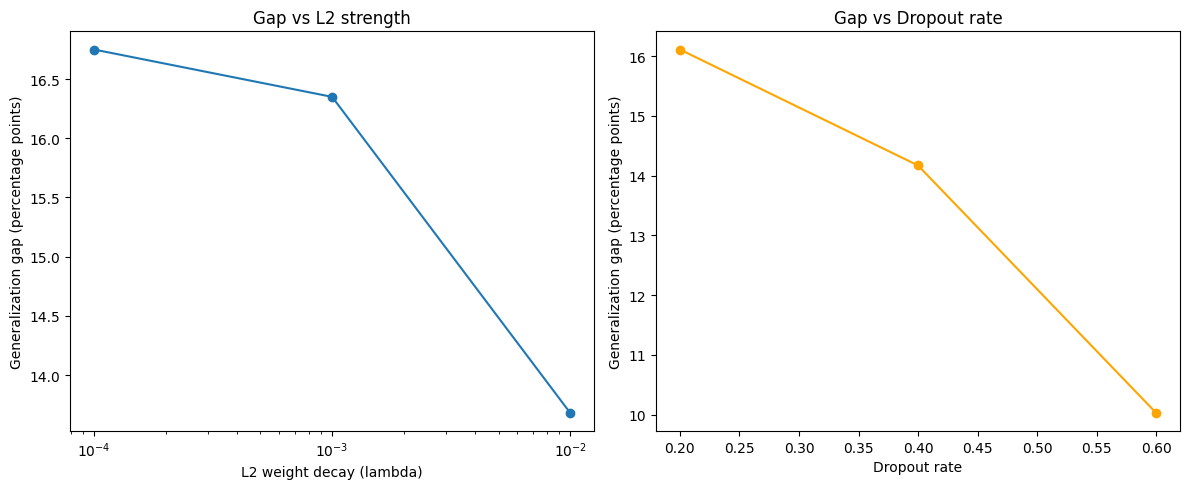

In [16]:

import matplotlib.pyplot as plt


l2_strengths = [0.0001, 0.001, 0.01]
l2_gaps = [16.75, 16.35, 13.68]

dropout_rates = [0.2, 0.4, 0.6]
dropout_gaps = [16.11, 14.17, 10.03]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(l2_strengths, l2_gaps, marker="o")
axes[0].set_xscale("log")
axes[0].set_xlabel("L2 weight decay (lambda)")
axes[0].set_ylabel("Generalization gap (percentage points)")
axes[0].set_title("Gap vs L2 strength")

axes[1].plot(dropout_rates, dropout_gaps, marker="o", color="orange")
axes[1].set_xlabel("Dropout rate")
axes[1].set_ylabel("Generalization gap (percentage points)")
axes[1].set_title("Gap vs Dropout rate")

plt.tight_layout()
plt.show()

In [17]:

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.model_selection import KFold
import random
import time

torch.manual_seed(42)
random.seed(42)
np.random.seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


class SearchMLP(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=128, output_dim=10, dropout_rate=0.0):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_dim, output_dim),
        )

    def forward(self, x):
        return self.net(x)


def train_and_eval_fold(X_tr, y_tr, X_va, y_va, lr, hidden_dim, dropout_rate,
                         epochs=20, batch_size=128):
    model = SearchMLP(hidden_dim=hidden_dim, dropout_rate=dropout_rate).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    n = X_tr.shape[0]
    for epoch in range(epochs):
        model.train()
        permutation = torch.randperm(n)
        for i in range(0, n, batch_size):
            idx = permutation[i:i+batch_size]
            xb, yb = X_tr[idx], y_tr[idx]
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()

    model.eval()
    with torch.no_grad():
        preds = model(X_va).argmax(dim=1)
        acc = (preds == y_va).float().mean().item()
    return acc


search_space = {
    "lr": (0.0001, 0.01),    
    "hidden_dim": [64, 128, 256, 512],  
    "dropout_rate": (0.0, 0.5), 
}

print("Search space:")
print(f"  learning rate: log-uniform between {search_space['lr']}")
print(f"  hidden_dim: choice from {search_space['hidden_dim']}")
print(f"  dropout_rate: uniform between {search_space['dropout_rate']}")


def sample_config():
    log_lr = random.uniform(np.log10(search_space["lr"][0]), np.log10(search_space["lr"][1]))
    lr = 10 ** log_lr
    hidden_dim = random.choice(search_space["hidden_dim"])
    dropout_rate = random.uniform(*search_space["dropout_rate"])
    return {"lr": lr, "hidden_dim": hidden_dim, "dropout_rate": dropout_rate}


search_data_size = 8000
X_search = X_train[:search_data_size]
y_search = y_train[:search_data_size]

n_configs = 12
n_folds = 5

configs = [sample_config() for _ in range(n_configs)]
kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)

search_results = []

start_time = time.time()
for cfg_idx, cfg in enumerate(configs):
    fold_accs = []
    for fold_idx, (train_idx, val_idx) in enumerate(kf.split(X_search)):
        X_tr = torch.tensor(X_search[train_idx], dtype=torch.float32).to(device)
        y_tr = torch.tensor(y_search[train_idx], dtype=torch.long).to(device)
        X_va = torch.tensor(X_search[val_idx], dtype=torch.float32).to(device)
        y_va = torch.tensor(y_search[val_idx], dtype=torch.long).to(device)

        acc = train_and_eval_fold(X_tr, y_tr, X_va, y_va,
                                    lr=cfg["lr"], hidden_dim=cfg["hidden_dim"],
                                    dropout_rate=cfg["dropout_rate"])
        fold_accs.append(acc)

    mean_acc = np.mean(fold_accs)
    std_acc = np.std(fold_accs)
    search_results.append({"config": cfg, "mean_acc": mean_acc, "std_acc": std_acc})

    elapsed = time.time() - start_time
    print(f"Config {cfg_idx+1}/{n_configs}: lr={cfg['lr']:.5f}, hidden_dim={cfg['hidden_dim']}, "
          f"dropout={cfg['dropout_rate']:.3f} -> mean_acc={mean_acc*100:.2f}% "
          f"(+/- {std_acc*100:.2f}%) [{elapsed:.0f}s elapsed]")


search_results.sort(key=lambda r: r["mean_acc"], reverse=True)

print("\nTop 5 configurations")
for i, r in enumerate(search_results[:5]):
    cfg = r["config"]
    print(f"{i+1}. lr={cfg['lr']:.5f}, hidden_dim={cfg['hidden_dim']}, dropout={cfg['dropout_rate']:.3f} "
          f"-> mean={r['mean_acc']*100:.2f}%, std={r['std_acc']*100:.2f}%")

best_config = search_results[0]["config"]
print(f"\nSelected configuration: {best_config}")

Search space:
  learning rate: log-uniform between (0.0001, 0.01)
  hidden_dim: choice from [64, 128, 256, 512]
  dropout_rate: uniform between (0.0, 0.5)
Config 1/12: lr=0.00190, hidden_dim=64, dropout=0.371 -> mean_acc=84.33% (+/- 1.12%) [12s elapsed]
Config 2/12: lr=0.00031, hidden_dim=128, dropout=0.368 -> mean_acc=83.36% (+/- 0.97%) [27s elapsed]
Config 3/12: lr=0.00226, hidden_dim=64, dropout=0.295 -> mean_acc=84.56% (+/- 0.67%) [38s elapsed]
Config 4/12: lr=0.00012, hidden_dim=64, dropout=0.109 -> mean_acc=79.00% (+/- 1.12%) [48s elapsed]
Config 5/12: lr=0.00102, hidden_dim=64, dropout=0.281 -> mean_acc=84.40% (+/- 1.10%) [59s elapsed]
Config 6/12: lr=0.00270, hidden_dim=512, dropout=0.110 -> mean_acc=84.95% (+/- 1.15%) [109s elapsed]
Config 7/12: lr=0.00151, hidden_dim=64, dropout=0.379 -> mean_acc=84.20% (+/- 0.98%) [121s elapsed]
Config 8/12: lr=0.00021, hidden_dim=512, dropout=0.170 -> mean_acc=85.54% (+/- 0.64%) [165s elapsed]
Config 9/12: lr=0.00020, hidden_dim=256, dropou

 Retraining final model on full training set 48,000 samples
Epoch 5/30 - train_loss: 0.3006 - test_acc so far: 88.25%
Epoch 10/30 - train_loss: 0.2399 - test_acc so far: 88.77%
Epoch 15/30 - train_loss: 0.1978 - test_acc so far: 89.61%
Epoch 20/30 - train_loss: 0.1697 - test_acc so far: 89.00%
Epoch 25/30 - train_loss: 0.1456 - test_acc so far: 89.82%
Epoch 30/30 - train_loss: 0.1280 - test_acc so far: 89.72%

FINAL TEST SET RESULTS 
Accuracy:        89.72%
Macro precision: 89.83%
Macro recall:    89.72%
Macro F1:        89.75%


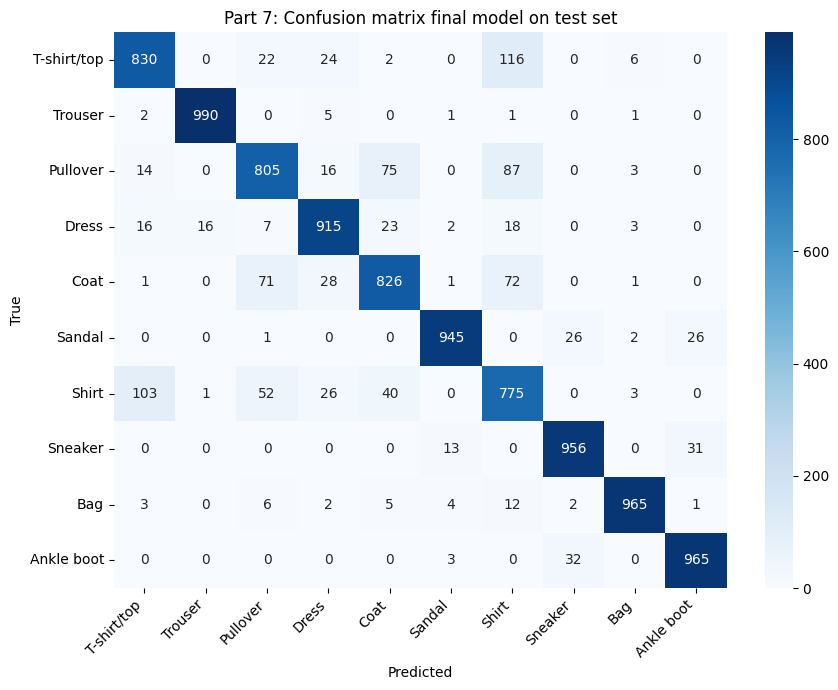


Set part2_baseline_acc above to compute the improvement over your Part 2 baseline.


In [18]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns


final_lr = 0.0011815610957838962
final_hidden_dim = 512
final_dropout = 0.039400099039229086

torch.manual_seed(42)

X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train, dtype=torch.long).to(device)
X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test_t = torch.tensor(y_test, dtype=torch.long).to(device)

final_model = SearchMLP(hidden_dim=final_hidden_dim, dropout_rate=final_dropout).to(device)
optimizer = optim.Adam(final_model.parameters(), lr=final_lr)
criterion = nn.CrossEntropyLoss()

epochs = 30
batch_size = 128
n = X_train_t.shape[0]

print(" Retraining final model on full training set 48,000 samples")
for epoch in range(epochs):
    final_model.train()
    permutation = torch.randperm(n)
    epoch_loss = 0.0
    n_batches = 0
    for i in range(0, n, batch_size):
        idx = permutation[i:i+batch_size]
        xb, yb = X_train_t[idx], y_train_t[idx]
        optimizer.zero_grad()
        out = final_model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        n_batches += 1

    if (epoch + 1) % 5 == 0:
        final_model.eval()
        with torch.no_grad():
            test_preds_tmp = final_model(X_test_t).argmax(dim=1)
            tmp_acc = (test_preds_tmp == y_test_t).float().mean().item()
        print(f"Epoch {epoch+1}/{epochs} - train_loss: {epoch_loss/n_batches:.4f} - test_acc so far: {tmp_acc*100:.2f}%")


final_model.eval()
with torch.no_grad():
    test_logits = final_model(X_test_t)
    test_preds = test_logits.argmax(dim=1).cpu().numpy()

y_test_np = y_test 

test_accuracy = accuracy_score(y_test_np, test_preds)
macro_precision = precision_score(y_test_np, test_preds, average="macro")
macro_recall = recall_score(y_test_np, test_preds, average="macro")
macro_f1 = f1_score(y_test_np, test_preds, average="macro")

print("\nFINAL TEST SET RESULTS ")
print(f"Accuracy:        {test_accuracy*100:.2f}%")
print(f"Macro precision: {macro_precision*100:.2f}%")
print(f"Macro recall:    {macro_recall*100:.2f}%")
print(f"Macro F1:        {macro_f1*100:.2f}%")

cm = confusion_matrix(y_test_np, test_preds)

class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Part 7: Confusion matrix final model on test set")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


part2_baseline_acc = None 

if part2_baseline_acc is not None:
    improvement = (test_accuracy - part2_baseline_acc) * 100
    print(f"\nImprovement over Part 2 baseline: {improvement:+.2f} percentage points")
else:
    print("\nSet part2_baseline_acc above to compute the improvement over your Part 2 baseline.")